# 00 - Raw duty sweep characterization

## Purpose

This notebook is the first in a series working toward an accurate,
mathematically proven servo control loop, built on empirical data. The
series starts from raw ADC readings and derives every quantity in the open.
Later notebooks compare these derivations against what the firmware
computes on the servo.

This notebook has three jobs:

1. Document the measurement chain and the constants that convert ADC
   readings into volts and amperes (section 2).
2. Measure the offset, noise, and limits of each raw channel (section 5).
3. Check that the data follows the expected brushed DC motor behavior
   (section 6).

The dataset is two test series with identical method, one powered from a
5 V USB source and one from a 2-cell lithium battery.


## 1. Test setup

The device under test is an SG90-class hobby servo with its stock
electronics replaced by a custom controller board. The signal chain:

- A brushed DC motor driven by an H-bridge with 20 kHz PWM, center
  aligned. The controller commands **duty**. Duty is the fraction of each
  PWM period during which the bridge applies the supply across the motor.
  Duty is signed. Negative duty drives the opposite direction. For the
  rest of the period the bridge shorts the winding through its low-side
  switches (slow decay), the mode used throughout this dataset.
- A gear train couples the motor to the output shaft. A potentiometer on
  the output shaft is read by the MCU's 12-bit ADC. The pot wiper connects
  directly to an ADC pin, so position readings convert to volts at the
  wiper with no divider. Converting wiper volts to output angle requires an
  angle calibration, which a later notebook derives, so position stays in
  wiper volts here.
- A 33 mOhm shunt resistor in the motor return path, amplified with gain
  15.0, gives the motor current channel. The recorded value is the
  amplifier output at the ADC pin, offset included.
- Both motor terminals are read through 20 kOhm / 10 kOhm resistor
  dividers, channels `vmotor_a` and `vmotor_b`. The bottom leg of each
  divider returns to a bias node $V_B$ of about 0.62 V (nominally 0.623 V
  from a 430 Ohm / 100 Ohm divider off VDD), so a terminal that swings
  below ground keeps its ADC pin above ground and stays readable. Section 2
  gives the tap formula and section 5.3 measures the bias.
- Each 50 us control period the ADC scans seven channels, triggered at
  the crest of the PWM counter, in the order shunt, `vmotor_a`,
  `vmotor_b`, position, a calibration reference, supply sense, and an NTC
  thermistor. The shunt uses a shorter sample aperture than the other
  channels. A second shunt sample at the trough of the counter gives
  `current_trough`.
- The controller streams every sample at the control rate (20,000 per
  second), packed 16 samples to a frame with a CRC. Corrupted frames are
  dropped and counted, so corruption turns into missing samples (verified
  in section 4). The wire budget at this rate allows six fields per
  sample. These recordings selected the six raw fields (position, both
  shunt samples, applied duty, both terminals). Supply sense and the NTC
  are streamable as `vbus_raw` and `ntc_raw` but were left out, so those
  two columns are empty and play no part in the analysis.

Power for the two test series, captured in separate sessions on the same
day:

- **USB series.** A laptop USB port. The voltage reaching the motor is
  measured in section 6.2. It is well below the nominal 5 V and drops
  further under load.
- **Battery series.** A 2-cell lithium battery, nominal 7.4 V, measured
  in section 6.2. The pack was not recharged before the session. This supply
  is above the 4.8 to 6 V range usually quoted for SG90-class servos, so
  the full-duty steps in the battery series stress the mechanism beyond
  its usual rating.


## 2. Constants and unit conversions

All conversions from ADC counts to physical units use the constants below.

| Quantity | Value |
|---|---|
| ADC resolution | 12 bit (0..4095 counts) |
| ADC reference | VDD, nominal 3.300 V |
| Motor terminal divider | 20 kOhm top / 10 kOhm bottom, bottom leg returned to the terminal bias |
| Terminal bias $V_B$, nominal | 430 Ohm / 100 Ohm from VDD, 0.623 V |
| Terminal bias $V_B$, measured | per recording, from the segment-0 baseline (section 5.3) |
| Current shunt | 33 mOhm |
| Current amplifier gain | 15.0 |
| Control period | 50 us (20 kHz) |
| PWM counter | 1200 timer ticks per half period, center aligned |
| Duty encoding | signed, 32767 = 100% |
| Current sampling floor | 160 timer ticks = 13.3% duty |
| Voltage sampling floor | 210 timer ticks = 17.5% duty |

With the divider's bottom leg returned to the bias $V_B$, a terminal
voltage $V_t$ reaches the ADC pin as

$$\text{tap} = \frac{V_t}{3} + \frac{2}{3} V_B, \qquad V_t = 3\,\text{tap} - 2 V_B .$$

With the bridge off and no current, both taps read $V_B$ exactly, which
is how the bias is measured per recording (section 5.3). Every absolute
terminal voltage below uses the second form with the measured $V_B$ of
its recording. The difference of the two terminals is bias-free, since
both dividers share the one bias node, so that $v_A - v_B = 3\,(\text{tap}_A -
\text{tap}_B)$ in ADC volts.

Two caveats:

- The ADC reference is the chip's VDD supply. The 3.300 V figure is the
  design value, and the actual VDD of this unit was not measured. Every
  voltage below scales linearly with the true VDD, so one future
  measurement of VDD rescales everything by one factor.
- The divider ratio, shunt, and gain are design values. Component
  tolerances were not measured, and absolute voltages and currents carry
  them. The bias itself is measured, so it adds no tolerance of its own.

The derived conversion factors:


In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- documented constants (see the table above) ---
VDD_V = 3.300               # ADC reference, nominal, not measured
ADC_COUNTS = 4096           # 12-bit converter
DIV_TOP_OHM = 20_000        # motor terminal divider, top leg
DIV_BOT_OHM = 10_000        # motor terminal divider, bottom leg
BIAS_TOP_OHM = 430          # terminal bias divider from VDD, top leg
BIAS_BOT_OHM = 100          # terminal bias divider, bottom leg
SHUNT_OHM = 0.033           # current shunt
AMP_GAIN = 15.0             # current amplifier gain
TICK_HZ = 20_000            # control / sample rate
PWM_HALF_TICKS = 1200       # timer ticks per PWM half period
Q15 = 32767                 # duty full scale as encoded on the wire
FLOOR_I_TICKS = 160         # current sampling floor
FLOOR_V_TICKS = 210         # voltage sampling floor

# --- derived conversion factors ---
V_ADC_PER_COUNT = VDD_V / ADC_COUNTS                       # volts at the ADC pin
V_TERM_PER_COUNT = V_ADC_PER_COUNT * (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM
DIV_RATIO = (DIV_TOP_OHM + DIV_BOT_OHM) / DIV_BOT_OHM      # 3: tap = Vt/3 + 2/3 VB
VB_NOM_V = VDD_V * BIAS_BOT_OHM / (BIAS_TOP_OHM + BIAS_BOT_OHM)
A_PER_COUNT = V_ADC_PER_COUNT / (AMP_GAIN * SHUNT_OHM)     # amps through the shunt
FLOOR_I_PCT = FLOOR_I_TICKS * 100.0 / PWM_HALF_TICKS
FLOOR_V_PCT = FLOOR_V_TICKS * 100.0 / PWM_HALF_TICKS

def term_V(tap_counts, vb_counts):
    # Absolute terminal voltage from a tap reading: Vt = 3 tap - 2 VB.
    return (DIV_RATIO * tap_counts - (DIV_RATIO - 1) * vb_counts) * V_ADC_PER_COUNT

pd.DataFrame([
    {"quantity": "pot wiper", "value": V_ADC_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "motor terminal difference", "value": V_TERM_PER_COUNT * 1e3, "unit": "mV per count"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V * 1e3, "unit": "mV"},
    {"quantity": "terminal bias, nominal", "value": VB_NOM_V / V_ADC_PER_COUNT, "unit": "counts"},
    {"quantity": "motor current", "value": A_PER_COUNT * 1e3, "unit": "mA per count"},
    {"quantity": "current sampling floor", "value": FLOOR_I_PCT, "unit": "% duty"},
    {"quantity": "voltage sampling floor", "value": FLOOR_V_PCT, "unit": "% duty"},
]).set_index("quantity").round(4)


,value,unit
quantity,,
pot wiper,0.8057,mV per count
motor terminal difference,2.4170,mV per count
"terminal bias, nominal",622.6415,mV
"terminal bias, nominal",772.8302,counts
motor current,1.6276,mA per count
current sampling floor,13.3333,% duty
voltage sampling floor,17.5000,% duty


## 3. Capture method

The recordings live in the repository under `notebooks/telemetry/sg90/`,
ten per supply. One recording contains 41 segments, captured back to back:

- **Segment 0** is a one-second baseline with the motor undriven. It
  measures the noise floor of each channel, the current amplifier's
  offset, and the terminal bias.
- **Segments 1 to 40** are constant-duty drive steps, duty from 5% to 100%
  in 5% increments, first forward then reverse. Each step drives for 80 ms
  with full-rate capture, followed by 500 ms of rest. Before each step the
  servo is repositioned at 15% duty toward the far end of travel, so there
  is room to accelerate.

Between recordings the servo was rebooted and rested for one minute, so
every recording starts from the same software state and similar thermal
state. Both series follow this method exactly. The differences are the
supply and the session.

**Braking between steps.** After each step's capture window closes, the
sweep tool commands a 0.25% duty with slow-decay switching, which
short-circuits the motor winding for 99.75% of every PWM period and brakes
the motor to rest. The braking happens after the capture window, so the
recorded data is unaffected.

**Data acceptance.** Any recording in which the host counted even one
dropped frame was discarded and re-run. Section 4 re-verifies this from
the data itself.

Each row of a recording is one 50 us sample, holding the segment
number, commanded duty, direction, tick counter, the firmware's
sampling-validity flag (section 5.4), the raw channels (position, crest
and trough shunt samples, applied duty, both motor terminals), and the
two empty columns for supply sense and the NTC. The loader attaches to every recording its
two baseline constants, the current offset (mean of `current_raw` over
segment 0) and the terminal bias $V_B$ (median of `vmotor_a` over segment
0, cross-checked against `vmotor_b`).


In [2]:
TELEMETRY = Path("telemetry/sg90")

def load_recording(rec_dir):
    # One recording = sweep.csv.gz (per-tick samples) + meta.json (settings).
    # Derived columns: duty_pct (signed percent), t_ms (ms since start),
    # and the per-recording baseline constants bias, vb, vb_b.
    df = pd.read_csv(rec_dir / "sweep.csv.gz")
    meta = json.loads((rec_dir / "meta.json").read_text())
    df["duty_pct"] = df["cmd_duty_q15"] * 100.0 / Q15
    df["t_ms"] = (df["tick"] - df["tick"].iloc[0]) / (TICK_HZ / 1000)
    base = df[df["seg"] == 0]
    df["bias"] = base["current_raw"].mean()
    df["vb"] = base["vmotor_a"].median()
    df["vb_b"] = base["vmotor_b"].median()
    return df, meta

def load_series(base):
    recs = {}
    for d in sorted(base.glob("capture-*"), key=lambda p: int(p.name.split("-")[1])):
        recs[d.name] = load_recording(d)
    return recs

usb = load_series(TELEMETRY / "usb")
batt = load_series(TELEMETRY / "2s")
pd.DataFrame({"recordings": [len(usb), len(batt)]}, index=["usb", "2s battery"])


,recordings
usb,10
2s battery,10


## 4. Data integrity

The transport turns a corrupted frame into a missing sample. One frame
carries 16 consecutive samples, so a dropped frame appears as a 16-tick
jump in the tick column. The table below recomputes the missing-sample
count for every recording from the tick column.


In [3]:
def integrity(recs):
    rows = []
    for name, (df, meta) in recs.items():
        missing = 0
        for _, seg in df.groupby("seg"):
            ticks = seg["tick"].to_numpy()
            missing += int(ticks[-1] - ticks[0] + 1 - len(ticks))
        rows.append({
            "recording": name,
            "samples": len(df),
            "segments": df["seg"].nunique(),
            "missing_samples": missing,
        })
    return pd.DataFrame(rows)

pd.concat([
    integrity(usb).assign(series="usb"),
    integrity(batt).assign(series="2s battery"),
], ignore_index=True)


,recording,samples,segments,missing_samples,series
0,capture-1,84000,41,0,usb
1,capture-2,84000,41,0,usb
2,capture-3,84000,41,0,usb
3,capture-4,84000,41,0,usb
4,capture-5,84000,41,0,usb
5,capture-6,84000,41,0,usb
6,capture-7,84000,41,0,usb
7,capture-8,84000,41,0,usb
8,capture-9,84000,41,0,usb
9,capture-10,84000,41,0,usb


Every recording holds 84,000 samples in 41 segments with zero missing
samples.

## 5. Channel characterization

### 5.1 Position

The position channel is the pot wiper voltage. The baseline segment of
each recording gives its noise floor at rest. The repositioning move
before the baseline ends with the motor unpowered, and at battery voltage
the mechanism can still be coasting to rest when the capture starts. The
code below measures this residual motion two ways, as the offset of the
first 100 ms from the settled level and as the time of the last sample
outside the settled noise band. The noise statistics drop the first 200 ms
of the one-second baseline and use the settled remainder.


In [4]:
rows = []
for series, recs in [("usb", usb), ("2s battery", batt)]:
    for name, (df, _) in recs.items():
        base = df[df["seg"] == 0]["pos"].to_numpy() * V_ADC_PER_COUNT
        settled = base[len(base) // 5:]
        med = np.median(settled)
        band = np.max(np.abs(settled - med))
        outside = np.where(np.abs(base - med) > band)[0]
        rows.append({
            "series": series,
            "peak_dev_mV": band * 1e3,
            "std_mV": np.std(settled) * 1e3,
            # residual coast from the repositioning move: how far the
            # first 100 ms sits from the settled level, and when the
            # trace last leaves the settled band
            "coast_first_100ms_mV": abs(np.median(base[:2000]) - med) * 1e3,
            "coast_settle_ms": (outside[-1] + 1) / (TICK_HZ / 1000) if len(outside) else 0.0,
        })
pd.DataFrame(rows).groupby("series").agg(["mean", "max"]).round(2)


peak_dev_mV       std_mV       coast_first_100ms_mV        \
                  mean   max   mean   max                 mean   max   
series                                                                 
2s battery        6.53  8.86   1.60  1.76                 6.69  9.67   
usb               5.88  6.45   1.58  2.02                 0.32  1.61   

           coast_settle_ms          
                      mean     max  
series                              
2s battery          103.12  168.35  
usb                   5.25   28.90

The rest noise has a standard deviation of about 2 mV and a peak
deviation under 9 mV at the wiper (one ADC count is 0.81 mV). On the
battery series the coast lasts up to 168 ms, inside the 200 ms trimmed
from every baseline. On USB the mechanism is at rest within 29 ms.
Section 6.1 uses the peak deviation as the bound for deciding whether a
drive step produced real motion.

### 5.2 Current offset

The bridge is disabled during the baseline, so no current flows through
the shunt and the baseline reading is the amplifier's output offset. It is
measured below from every baseline segment of both series.


In [5]:
rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    offs = np.array([df["bias"].iloc[0] for df, _ in recs.values()])
    off_v = offs.mean() * V_ADC_PER_COUNT
    rows.append({
        "series": label,
        "offset_counts": offs.mean(),
        "offset_counts_min": offs.min(),
        "offset_counts_max": offs.max(),
        "offset_mV": off_v * 1e3,
        "offset_mA_equivalent": off_v / (AMP_GAIN * SHUNT_OHM) * 1e3,
        "recording_spread_mV": offs.std() * V_ADC_PER_COUNT * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2)


,offset_counts,offset_counts_min,offset_counts_max,offset_mV,offset_mA_equivalent,recording_spread_mV
series,,,,,,
usb,109.08,108.03,109.98,87.89,177.55,0.51
2s battery,102.89,102.07,103.85,82.90,167.47,0.40


Within a series the offset is stable to about half a millivolt across
ten reboot-separated recordings. Between the two sessions it differs by
about 6 counts (5 mV), the USB session at 108 to 110 counts and the
battery session at 102 to 104 counts. It is large, roughly 170 to 180 mA
equivalent, so it must be subtracted before current readings mean
anything, and the session difference alone is worth about 10 mA. Later
notebooks subtract the per-recording baseline value. *Hypothesis (not
tested here): the session difference tracks the board's supply or
temperature. Testing it requires baselines on both supplies within one
session.*

### 5.3 Terminal bias

With the bridge off and no current in the winding, both terminal dividers
sit at the bias node, so the baseline reads $V_B$ directly on both
channels. The median over the full one-second baseline is robust against
the coasting motor's back-EMF in the first tens of milliseconds. The table
compares the two channels and the nominal value per series.


In [6]:
rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    vb = np.array([df["vb"].iloc[0] for df, _ in recs.values()])
    vb_b = np.array([df["vb_b"].iloc[0] for df, _ in recs.values()])
    rows.append({
        "series": label,
        "VB_counts_min": vb.min(),
        "VB_counts_max": vb.max(),
        "VB_mV": vb.mean() * V_ADC_PER_COUNT * 1e3,
        "B_minus_A_counts_min": (vb_b - vb).min(),
        "B_minus_A_counts_max": (vb_b - vb).max(),
        "VB_minus_nominal_mV": (vb.mean() * V_ADC_PER_COUNT - VB_NOM_V) * 1e3,
    })
pd.DataFrame(rows).set_index("series").round(2)


,VB_counts_min,VB_counts_max,VB_mV,B_minus_A_counts_min,B_minus_A_counts_max,VB_minus_nominal_mV
series,,,,,,
usb,776.0,776.0,625.20,2.0,2.0,2.55
2s battery,776.0,777.0,625.92,1.0,2.0,3.28


The bias reads 776 to 777 counts (about 0.625 V) on every recording of
both series, 2.5 to 3.3 mV above nominal, and `vmotor_b` sits 1 to 2
counts above `vmotor_a`. Every absolute terminal voltage below uses the
recording's own `vmotor_a` median as $V_B$. A 2-count uncertainty in
$V_B$ enters an absolute terminal voltage doubled, worth 3 mV, and is
left uncorrected.

### 5.4 Sampling floors and the validity flag

The scan is triggered at the crest of the PWM counter, which under slow
decay is the center of the drive window. The crest sample therefore sits
inside the drive window at every nonzero duty. Whether it is settled
depends on how far the window's edge is from the scan. The firmware
states two floors, 160 of the 1200 half-period ticks for current (13.3%
duty) and 210 for terminal voltage (17.5%), and stamps every sample with
a validity flag that encodes the current floor. The voltage floor is the
stricter one and is set where both terminal dividers have settled. The
figure below shows the driven terminal's raw samples at three duty
levels, then the table checks where the recorded flag flips.


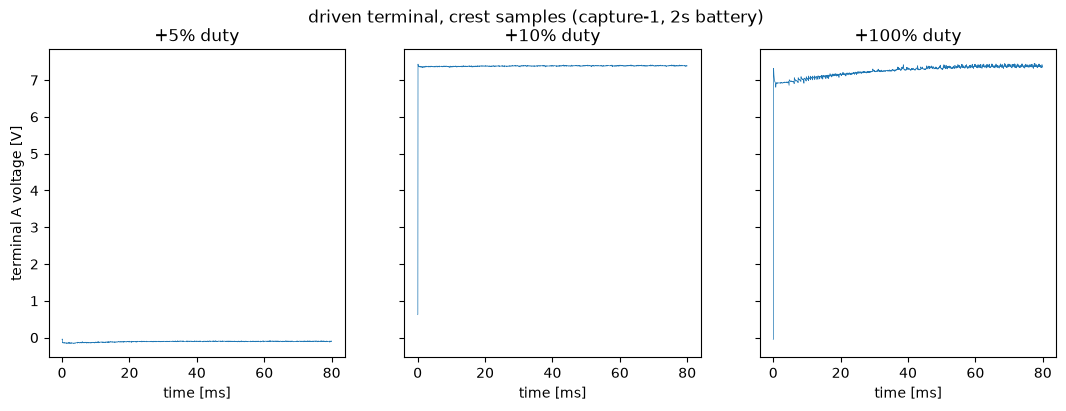

,recordings,distinct_flip_points,invalid_up_to_pct,valid_from_pct
series,,,,
usb,10,1,10.0,15.0
2s battery,10,1,10.0,15.0


In [7]:
name, (df, meta) = next(iter(batt.items()))
vb = df["vb"].iloc[0]
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
for ax, pct in zip(axes, [5, 10, 100]):
    seg = df[np.isclose(df["duty_pct"], pct, atol=0.5)]
    t = (seg["tick"] - seg["tick"].iloc[0]) / (TICK_HZ / 1000)
    ax.plot(t, term_V(seg["vmotor_a"], vb), lw=0.5)
    ax.set_title(f"+{pct}% duty")
    ax.set_xlabel("time [ms]")
axes[0].set_ylabel("terminal A voltage [V]")
fig.suptitle(f"driven terminal, crest samples ({name}, 2s battery)")
plt.show()

# Where does the recorded validity flag flip? Checked in every recording
# of both series.
rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    flips = set()
    for df, _ in recs.values():
        v = df[df["seg"] > 0].groupby("seg").agg(
            d=("duty_pct", "first"), valid_frac=("window_valid", "mean"))
        v["mag"] = v["d"].abs().round()
        flips.add((v[v.valid_frac <= 0.5]["mag"].max(),
                   v[v.valid_frac > 0.5]["mag"].min()))
    rows.append({
        "series": label,
        "recordings": len(recs),
        "distinct_flip_points": len(flips),
        "invalid_up_to_pct": max(h for h, _ in flips),
        "valid_from_pct": min(l for _, l in flips),
    })
pd.DataFrame(rows).set_index("series")


At +100% duty the crest sample reads near the supply voltage in every
period. At +10% it already reads the supply. At +5% it reads about
-0.1 V, since the drive window's edge is 60 ticks from the scan and the
divider has not settled. The motor still receives its share of the supply
during that step, and the position data in section 6.1 shows the servo
moving at 10%.

The recorded flag flips between the 10% and 15% duty steps in every
recording of both series, consistent with the 160-tick current floor on
this 5% grid. The two terminals settle at different points. The table
below pools the driven terminal's median reading per step across all
recordings, terminal A for forward steps and terminal B for reverse.


In [8]:
rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    for df, _ in recs.values():
        vb = df["vb"].iloc[0]
        for seg_id, seg in df.groupby("seg"):
            d = seg["duty_pct"].iloc[0]
            mag = int(round(abs(d)))
            if seg_id == 0 or mag > 25:
                continue
            term = seg["vmotor_a"] if d > 0 else seg["vmotor_b"]
            rows.append({
                "series": label,
                "terminal": "A (forward)" if d > 0 else "B (reverse)",
                "duty_mag_pct": mag,
                "driven_V": term_V(term.median(), vb),
            })
(pd.DataFrame(rows)
   .groupby(["duty_mag_pct", "series", "terminal"])["driven_V"].mean()
   .unstack(["series", "terminal"]).round(2))


series        2s battery                     usb            
terminal     A (forward) B (reverse) A (forward) B (reverse)
duty_mag_pct                                                
5                  -0.10        0.00       -0.09       -0.00
10                  7.38        0.00        4.55       -0.00
15                  7.36        7.37        4.53        4.67
20                  7.35        7.35        4.51        4.65
25                  7.35        7.35        4.48        4.62

Terminal A reads the supply from the 10% step. Terminal B reads it
from the 15% step and near zero at 10%, so its edge lies between 10% and
15% duty. The 17.5% voltage floor clears both edges with the 5% grid's
next step at 20%. This imposes two rules on everything below:

- Current readings are used only where the validity flag is set. Terminal
  voltage is additionally restricted to duty at or above the 17.5% floor,
  which on this grid means the 20% step and up.
- Below those floors the position channel is the only trusted channel.
  The pot wiper is sampled directly, outside the PWM window, so position
  has no such limit.

## 6. Results

### 6.1 Motion threshold

For each drive step, net travel is the difference between the median of
the last 20 and the first 20 position samples (medians so a single noise
spike cannot fake motion). This is compared against the rest-noise band
from section 5.1. One complication needs handling. Each drive step begins
shortly after a repositioning move, and the mechanism can still be
coasting from that move when the step begins (section 5.1 measures this in
the baselines). Drive-produced motion follows the commanded direction.
Residual coast follows the repositioning move, which by construction of
the test runs opposite the drive direction. So besides the per-step
scatter, the table pools travel aligned with the drive direction across
all recordings.


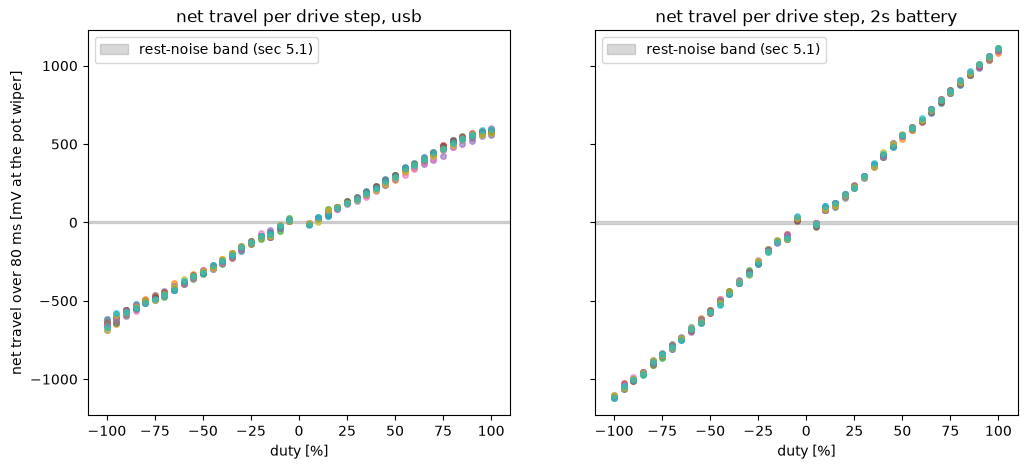

usb                    2s battery                   
               mean   std    min count       mean   std    min count
duty_mag_pct                                                        
5.0           -10.4   5.4  -27.4    20      -17.5  10.1  -38.3    20
10.0           26.6   9.5    5.2    20       92.1  12.8   74.9    20
15.0           70.0  18.3   38.7    20      119.1   8.2   99.1    20
20.0           90.7   7.3   70.1    20      177.0   7.8  157.5    20
25.0          126.6   5.9  117.6    20      241.7  15.8  218.7    20

In [9]:
def step_travel(df):
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        p = seg["pos"].to_numpy() * V_ADC_PER_COUNT * 1e3   # mV at the wiper
        out.append({
            "duty_pct": seg["duty_pct"].iloc[0],
            "travel_mV": np.median(p[-20:]) - np.median(p[:20]),
        })
    return pd.DataFrame(out)

def rest_band_mV(df):
    base = df[df["seg"] == 0]["pos"].to_numpy() * V_ADC_PER_COUNT * 1e3
    settled = base[len(base) // 5:]
    return np.max(np.abs(settled - np.median(settled)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
bands = {}
for ax, recs, title in [(axes[0], usb, "usb"), (axes[1], batt, "2s battery")]:
    band = 0.0
    for name, (df, meta) in recs.items():
        tr = step_travel(df)
        band = max(band, rest_band_mV(df))
        ax.plot(tr["duty_pct"], tr["travel_mV"], "o", ms=4, alpha=0.6)
    bands[title] = band
    ax.axhspan(-band, band, color="grey", alpha=0.3,
               label="rest-noise band (sec 5.1)")
    ax.set_xlabel("duty [%]")
    ax.set_title(f"net travel per drive step, {title}")
    ax.legend(loc="upper left")
axes[0].set_ylabel("net travel over 80 ms [mV at the pot wiper]")
plt.show()

# Drive-aligned travel by |duty| in mV; positive = moved in the
# commanded direction.
tables = {}
for label, recs in [("usb", usb), ("2s battery", batt)]:
    allt = pd.concat([step_travel(df) for df, _ in recs.values()])
    allt["aligned_mV"] = allt["travel_mV"] * np.sign(allt["duty_pct"])
    tables[label] = (allt.assign(duty_mag_pct=np.abs(allt["duty_pct"]).round())
                         .groupby("duty_mag_pct")["aligned_mV"]
                         .agg(["mean", "std", "min", "count"]).head(5))
aligned = pd.concat(tables, axis=1)
aligned.round(1)


Findings:

- At 10% duty the servo moves on both supplies. The mean aligned travel is
  roughly +27 mV per 80 ms step on USB and +92 mV on battery, in the
  commanded direction. On battery the smallest of the twenty steps clears
  the rest-noise band by an order of magnitude. On USB the smallest step
  (5 mV) sits inside the band, so motion there rests on the pooled mean, four
  times the band and opposed by the residual coast.
- At 5% duty the aligned travel is slightly negative with a tight spread on
  both supplies. Drive cannot produce motion opposite the command. Residual
  coast can, and its direction opposes the drive direction here by
  construction. The 5% steps are therefore consistent with zero
  drive-produced motion.

So the motion threshold of this unit lies between 5% and 10% duty on both
supplies. Section 6.2 converts this duty bracket into a voltage bracket
once the supply is measured.

### 6.2 Supply voltage under load

These recordings carry no supply-sense samples (section 1). They have the
two motor terminals. While the bridge drives, the driven terminal connects
to the supply through the high-side switch, so its voltage is the supply
minus the switch drop. The estimate below takes, per drive step, the 90th
percentile of the driven terminal's valid samples (terminal A when driving
forward, terminal B in reverse), bias-corrected with the recording's
$V_B$ and restricted to duty at or above the 17.5% voltage floor. Steps
below the floor have no valid voltage samples and are absent from the
figure. The table also reports the partner terminal at full duty, which
the low-side switch holds near ground, as a check on the bias correction.


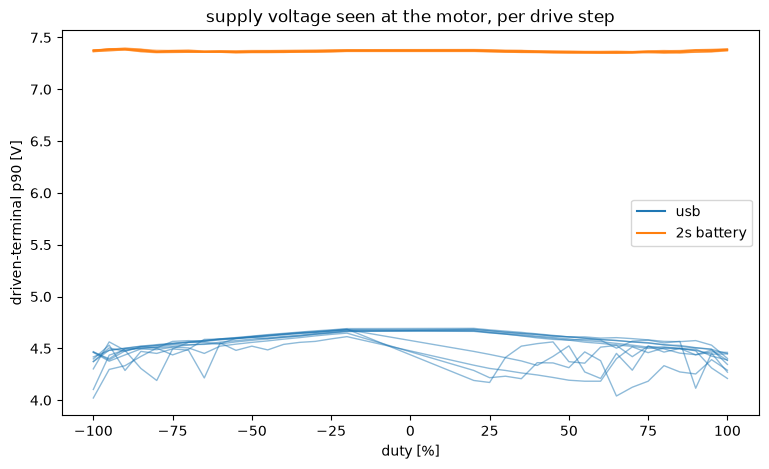

,light_load_V,full_duty_V,drop_mV,low_side_full_duty_V
series,,,,
usb,4.59,4.35,237.11,0.08
2s battery,7.37,7.38,-6.01,0.12


In [10]:
def step_supply(df):
    # Supply estimate per drive step: p90 of the driven terminal, valid
    # samples at or above the voltage floor only. low_side_V is the
    # median of the partner terminal over the same samples.
    vb = df["vb"].iloc[0]
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        d = seg["duty_pct"].iloc[0]
        if abs(d) < FLOOR_V_PCT:
            continue
        v = seg[seg["window_valid"] == 1]
        if len(v) < 100:
            continue
        hi, lo = (v["vmotor_a"], v["vmotor_b"]) if d > 0 else (v["vmotor_b"], v["vmotor_a"])
        out.append({"duty_pct": d,
                    "supply_V": term_V(hi.quantile(0.9), vb),
                    "low_side_V": term_V(lo.median(), vb)})
    return pd.DataFrame(out).sort_values("duty_pct")

fig, ax = plt.subplots(figsize=(9, 5))
for recs, color, label in [(usb, "tab:blue", "usb"),
                           (batt, "tab:orange", "2s battery")]:
    for name, (df, _) in recs.items():
        r = step_supply(df)
        ax.plot(r["duty_pct"], r["supply_V"], "-", lw=1, alpha=0.5, color=color)
    ax.plot([], [], "-", color=color, label=label)
ax.set_xlabel("duty [%]")
ax.set_ylabel("driven-terminal p90 [V]")
ax.set_title("supply voltage seen at the motor, per drive step")
ax.legend()
plt.show()

rows = []
for label, recs in [("usb", usb), ("2s battery", batt)]:
    hi, lo, ls = [], [], []
    for df, _ in recs.values():
        r = step_supply(df)
        full = r[r["duty_pct"].abs() >= 95]
        lo.append(full["supply_V"].mean())
        ls.append(full["low_side_V"].mean())
        hi.append(r[r["duty_pct"].abs() <= 30]["supply_V"].mean())
    rows.append({
        "series": label,
        "light_load_V": np.mean(hi),
        "full_duty_V": np.mean(lo),
        "drop_mV": (np.mean(hi) - np.mean(lo)) * 1e3,
        "low_side_full_duty_V": np.mean(ls),
    })
supply = pd.DataFrame(rows).set_index("series")
supply.round(2)


Findings:

- The USB series delivers about 4.6 V at light load, already well below
  the nominal 5 V, and drops by roughly another 0.24 V as duty rises to
  100%. *Hypothesis (not tested here): the standing deficit and the load
  dependence are resistive and diode drops in the cable, connectors, and
  the board's input path. Testing it requires measuring the voltage at the
  port and at the board input at the same time.*
- The battery series delivers about 7.4 V, flat within 10 mV across the
  duty range on this p90 measure.
- The low-side terminal reads 0.08 to 0.12 V at full duty after the bias
  correction, the drop across the conducting low-side switch. Without the
  correction it would read $2 V_B$ higher.

Every fit below that divides by supply voltage therefore uses the per-step
measured value.

**The motion threshold as a voltage.** If the threshold of section 6.1 is
a fixed voltage (the voltage needed to overcome friction), the relevant
axis is duty times the supply voltage. The table applies the light-load
supply of each series to its 5% and 10% steps and marks which of them
moved (aligned travel beyond the rest-noise band).


In [11]:
rows = []
for label in ["usb", "2s battery"]:
    for pct in [5, 10]:
        rows.append({
            "series": label,
            "duty_pct": pct,
            "applied_V": pct / 100.0 * supply.loc[label, "light_load_V"],
            "aligned_travel_mV": aligned.loc[pct, (label, "mean")],
            "moved": bool(aligned.loc[pct, (label, "mean")] > bands[label]),
        })
pd.DataFrame(rows).set_index(["series", "duty_pct"]).round(2)


applied_V  aligned_travel_mV  moved
series     duty_pct                                     
usb        5              0.23             -10.39  False
           10             0.46              26.63   True
2s battery 5              0.37             -17.52  False
           10             0.74              92.15   True

The highest step that did not move is the battery 5% step at 0.37 V.
The lowest step that moved is the USB 10% step at 0.46 V. The minimum
voltage that produces motion therefore lies between 0.37 and 0.46 V for
this unit. A single supply brackets this a factor of two wide. The second
supply squeezes the bracket to under 25%. Why a DC motor needs a minimum
voltage to start moving is a friction question, taken up in notebook 04.

### 6.3 Speed vs effective voltage

For each drive step above the motion threshold, the steady speed is the
slope of a least-squares line through the last 60% of the step's position
trace, past the initial acceleration. For a brushed DC motor at steady
speed, the average applied voltage is duty times the supply voltage, and
speed rises linearly with it. This section tests whether the raw data
follows that model across two supplies nearly 3 V apart.

Steps below the 17.5% voltage floor have no same-step supply
measurement. Those steps use the mean supply of the gentlest measurable
steps of the same recording (20% to 30% duty). Section 6.2 shows the
supply varies little at low duty, so the substitution costs a few tens of
millivolts at most. The fit table also repeats the fit with one supply
value per series (the mean over all measurable steps) to show what the
per-step correction is worth.


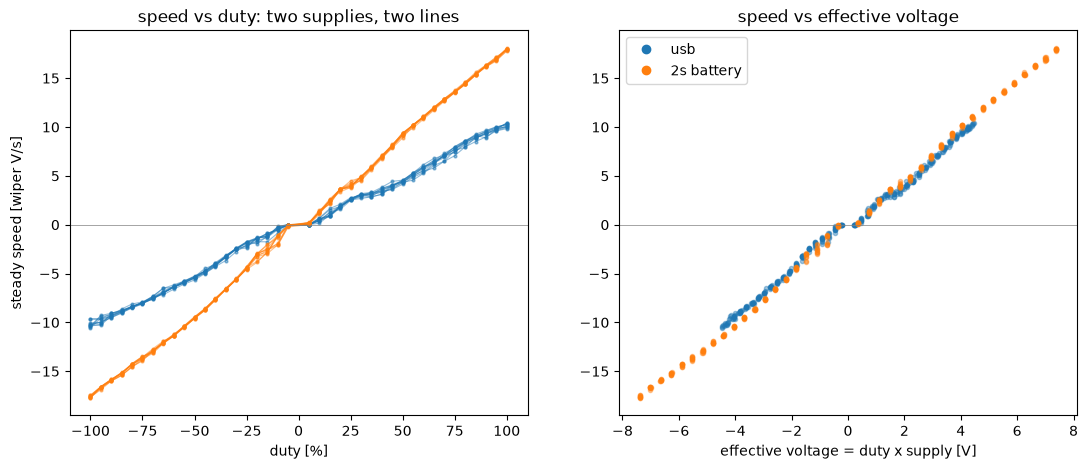

,usb slope_Vps_per_V,usb intercept_Vps,2s battery slope_Vps_per_V,2s battery intercept_Vps,slope_difference_pct
per-step supply,2.281,-0.106,2.451,-0.080,7.214
single supply per series,2.260,-0.133,2.452,-0.083,8.172


In [12]:
def step_speeds(df):
    sup = step_supply(df).set_index("duty_pct")["supply_V"]
    sup_lo = sup[np.abs(sup.index) <= 30].mean()
    out = []
    for seg_id, seg in df.groupby("seg"):
        if seg_id == 0:
            continue
        n = len(seg)
        tail = seg.iloc[int(n * 0.4):]
        t = (tail["tick"] - tail["tick"].iloc[0]) / TICK_HZ
        slope = np.polyfit(t, tail["pos"] * V_ADC_PER_COUNT, 1)[0]
        d = seg["duty_pct"].iloc[0]
        out.append({
            "duty_pct": d,
            "speed_Vps": slope,                       # wiper volts per second
            "supply_V": sup.get(d, sup_lo),
            "supply_mean_V": sup.mean(),
        })
    return pd.DataFrame(out)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for recs, color, label in [(usb, "tab:blue", "usb"),
                           (batt, "tab:orange", "2s battery")]:
    for name, (df, meta) in recs.items():
        sp = step_speeds(df).sort_values("duty_pct")
        axes[0].plot(sp["duty_pct"], sp["speed_Vps"], "-o", ms=2, lw=0.8,
                     alpha=0.5, color=color)
        veff = sp["duty_pct"] / 100.0 * sp["supply_V"]
        axes[1].plot(veff, sp["speed_Vps"], "o", ms=3, alpha=0.4, color=color)
    axes[1].plot([], [], "o", color=color, label=label)
axes[0].set_xlabel("duty [%]")
axes[0].set_ylabel("steady speed [wiper V/s]")
axes[0].set_title("speed vs duty: two supplies, two lines")
axes[1].set_xlabel("effective voltage = duty x supply [V]")
axes[1].set_title("speed vs effective voltage")
axes[1].legend()
for ax in axes:
    ax.axhline(0, color="grey", lw=0.5)
plt.show()

fits = {}
for recs, label in [(usb, "usb"), (batt, "2s battery")]:
    pts = pd.concat([step_speeds(df) for df, _ in recs.values()])
    for kind, col in [("per-step supply", "supply_V"),
                      ("single supply per series", "supply_mean_V")]:
        veff = pts["duty_pct"] / 100.0 * pts[col]
        m = veff.abs() > 1.0     # fit above 1 V, clear of the motion threshold
        k = np.polyfit(veff[m], pts["speed_Vps"][m], 1)
        fits.setdefault(kind, {})[f"{label} slope_Vps_per_V"] = k[0]
        fits[kind][f"{label} intercept_Vps"] = k[1]
fits = pd.DataFrame(fits).T
fits["slope_difference_pct"] = (
    (fits["2s battery slope_Vps_per_V"] - fits["usb slope_Vps_per_V"])
    / fits[["usb slope_Vps_per_V", "2s battery slope_Vps_per_V"]].mean(axis=1) * 100)
fits.round(3)


Findings:

- Against duty (left panel), the two series separate. The battery line
  is straight and steeper by roughly the ratio of the supply voltages,
  and the USB curve bends as its rail sags, so duty alone does not
  predict speed.
- Against effective voltage (right panel), the two series come close to
  one line. The fitted slopes agree to about 7% across the 4.6 V and
  7.4 V supplies, with the battery series the steeper. The linear
  speed-voltage relationship of the brushed DC motor model holds in this
  data to that level, with no calibration involved.
- The per-step supply is worth one percentage point. With a single supply
  value per series the slopes disagree by 8%. The remaining 7% is left
  open here. *Hypothesis (not tested here): the p90 rail estimate
  overstates the average voltage the USB supply delivered within a step,
  since the USB rail swings far more within a step than the battery.
  Testing it needs a per-sample effective voltage in place of the
  per-step p90, which needs the bridge-state gating of notebook 01.*

### 6.4 Repeatability across recordings

Each series is ten identical recordings separated by reboots and
one-minute rests, so drift across recordings reflects the hardware. The
figure shows the steady speed of the +100% duty step for every recording,
in order.


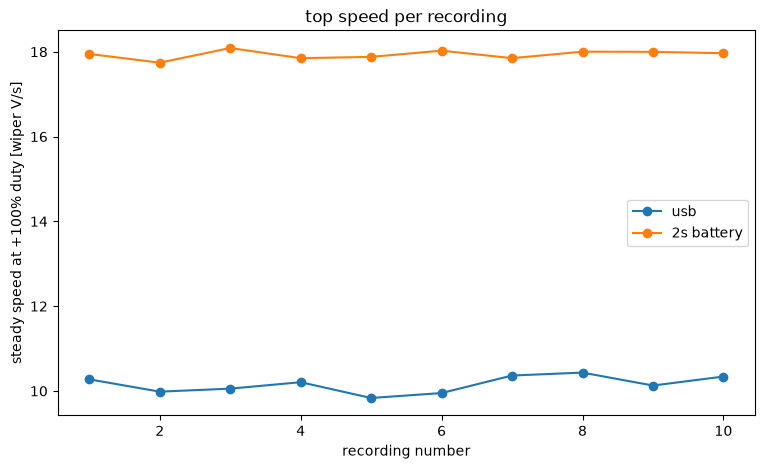

,spread_pct
series,
usb,5.9
2s battery,1.9


In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
rows = []
for recs, color, label in [(usb, "tab:blue", "usb"),
                           (batt, "tab:orange", "2s battery")]:
    xs, ys = [], []
    for name, (df, meta) in recs.items():
        n = int(name.split("-")[1])
        sp = step_speeds(df)
        row = sp[np.isclose(sp["duty_pct"], 100.0, atol=0.1)]
        xs.append(n)
        ys.append(row["speed_Vps"].iloc[0])
    ax.plot(xs, ys, "-o", color=color, label=label)
    rows.append({"series": label,
                 "spread_pct": (max(ys) - min(ys)) / np.mean(ys) * 100})
ax.set_xlabel("recording number")
ax.set_ylabel("steady speed at +100% duty [wiper V/s]")
ax.set_title("top speed per recording")
ax.legend()
plt.show()
pd.DataFrame(rows).set_index("series").round(1)


The ten recordings of each series agree within 6% (USB) and 2%
(battery) at full duty, with no systematic trend standing out of the
scatter. Plausible contributors include thermal changes in the gear train
and, on the battery series, the slow discharge of the pack over the
session. Neither is isolated or tested here. Any single recording carries
a few percent of unexplained variation, so fits in later notebooks pool
across recordings.

## 7. Limitations and open issues

- **One unit.** All numbers describe this one servo and this one board.
  The gear train has prior wear.
- **Voltages are nominal-referenced.** All voltages scale with the true
  VDD of this unit, which was not measured (section 2). The terminal bias
  is measured per recording, but the 3-to-1 divider ratio it enters with
  is a design value.
- **Position linearity is not established.** The pot's voltage-vs-angle
  linearity is not measured here. Nothing in this notebook depends on it.
  Fits that combine distant regions of travel will have to address it.
- **80 ms drive steps are short.** High-duty steps reach steady speed well
  inside the window. The slowest moving steps are still accelerating when
  the window ends, so their fitted speeds read slightly low.
- **The sampling floors are this board's.** The 13.3% and 17.5% floors
  change with board revision.
- **Supply sense and NTC are not in this dataset.** The six-field wire
  budget left `vbus_raw` and `ntc_raw` out, so the supply is inferred from
  the driven terminal (section 6.2) and temperature is unobserved.
- **The two series are different sessions.** The current offset differs
  between them (section 5.2), so nothing here pools baseline constants
  across supplies.
- **Battery series exceeds the servo's usual rating.** The full-duty
  battery steps apply about 7.4 V to a mechanism usually rated 4.8 to 6 V.

## 8. Next notebooks

The same measurement chain supports the next derivations, each one
checked against the firmware's on-servo computation:

- Notebook 01 establishes what each of the four bridge states does to the
  terminals, the shunt and the motion, and gates every later sample on
  the bridge state.
- Notebook 03 derives the back-EMF constant, notebook 04 the friction,
  including the 0.37 to 0.46 V motion threshold measured here, and notebook
  05 the inertia.
- The firmware's supply estimator and current-offset handling, re-derived
  from this raw data and compared against the servo's live values.
